# 04 — Combined Slip and the Friction Circle

In notebook 02 we built a longitudinal tire model (slip ratio → Fx).
In notebook 03 we built a lateral tire model (slip angle → Fy).

Both used the same Pacejka formula — but **independently**. That means if you simply
add the two notebooks together, you can get a car that simultaneously generates
maximum braking force AND maximum cornering force. That's physically impossible.

A real tire contact patch is a finite patch of rubber. It can only push sideways, or
push backwards, or some combination — but the **total force is bounded** by the available
friction. This is the **friction circle** (or friction ellipse).

This notebook covers:
1. Why the friction circle exists and what it means
2. How independent slip models violate it
3. The **slip vector decomposition** — the coupling that enforces the limit
4. `combined_slip_forces()` — the function that replaces separate Fx / Fy calls
5. Demos: braking while cornering, brake bias effect on balance

**Prerequisites:** notebooks 02 (slip ratio, longitudinal Pacejka) and 03 (slip angle,
lateral Pacejka, bicycle model).

In [2]:
import sys
sys.path.insert(0, 'lib')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from pacejka        import pacejka, pacejka_peak
from combined_slip  import combined_slip_forces
from bicycle_model  import BicycleModel, CombinedBicycleModel
from bicycle_model  import KAPPA_AT_FULL_BRAKE

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Imports OK')

Imports OK


## 1 — The friction circle: the fundamental limit

Every tire has a finite amount of grip to share between all directions.

Think of it as a **budget**: the total force the tire can generate in any direction
is bounded by μ_peak × Fz.  You can spend all of it on braking, all on cornering,
or split it — but you cannot exceed the total.

Mathematically:

$$\sqrt{F_x^2 + F_y^2} \leq \mu_{peak} \cdot F_z$$

In normalised form (divide by Fz):

$$\sqrt{\mu_x^2 + \mu_y^2} \leq \mu_{peak}$$

This traces a **circle** in the Fx–Fy plane.  In practice it's a slight **ellipse**
because tires have slightly different peak μ in the longitudinal vs lateral direction
(different rubber shear stiffness).  For F1 slicks the difference is small.

**Why this matters for lap time:**
- Hard braking at corner entry: almost all grip goes to Fx — almost no Fy left
- At the apex: brake pedal released — all grip available for Fy (maximum cornering speed)
- Traction at corner exit: some Fx for acceleration, Fy reduced
- The fastest drivers keep the tire at the edge of the circle **continuously** —
  this is the essence of 'working the tires'

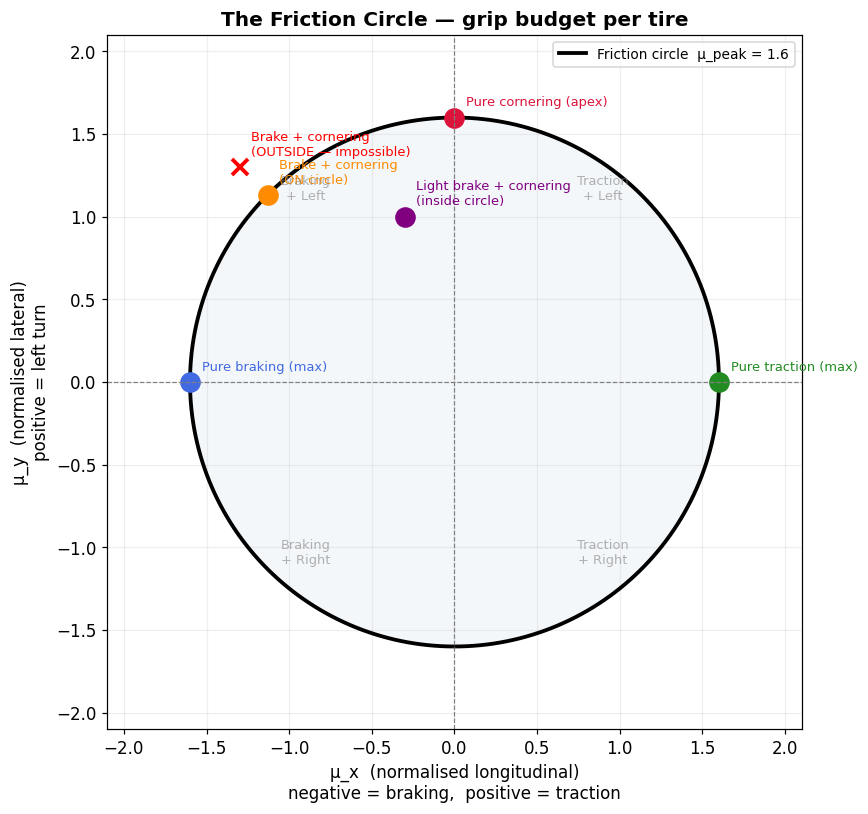

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

mu_peak = 1.6
theta   = np.linspace(0, 2*np.pi, 500)

# Friction circle
ax.plot(mu_peak * np.cos(theta), mu_peak * np.sin(theta),
        'k-', lw=2.5, label=f'Friction circle  μ_peak = {mu_peak}')
ax.fill(mu_peak * np.cos(theta), mu_peak * np.sin(theta),
        alpha=0.06, color='steelblue')

# Representative operating points
scenarios = [
    (  0.0,  mu_peak, 'Pure cornering (apex)',                   'crimson'),
    (-mu_peak, 0.0,   'Pure braking (max)',                      'royalblue'),
    ( mu_peak, 0.0,   'Pure traction (max)',                     'forestgreen'),
    ( -0.30,  1.00,   'Light brake + cornering\n(inside circle)', 'purple'),
    ( -1.13,  1.13,   'Brake + cornering\n(ON circle)',          'darkorange'),
    ( -1.30,  1.30,   'Brake + cornering\n(OUTSIDE — impossible)', 'red'),
]

for fx, fy, label, color in scenarios:
    total  = np.sqrt(fx**2 + fy**2)
    marker = 'x' if total > mu_peak + 0.05 else 'o'
    ax.plot(fx, fy, marker, color=color, ms=11, mew=2.5)
    ax.annotate(label, (fx, fy), xytext=(fx + 0.07, fy + 0.07), fontsize=8.5, color=color)

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')

ax.text( 0.9,  1.1, 'Traction\n+ Left', ha='center', fontsize=8.5, color='gray', alpha=0.6)
ax.text(-0.9,  1.1, 'Braking\n+ Left', ha='center', fontsize=8.5, color='gray', alpha=0.6)
ax.text(-0.9, -1.1, 'Braking\n+ Right',ha='center', fontsize=8.5, color='gray', alpha=0.6)
ax.text( 0.9, -1.1, 'Traction\n+ Right',ha='center',fontsize=8.5, color='gray', alpha=0.6)

ax.set_xlabel('μ_x  (normalised longitudinal)\nnegative = braking,  positive = traction')
ax.set_ylabel('μ_y  (normalised lateral)\npositive = left turn')
ax.set_title('The Friction Circle — grip budget per tire', fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2 — What breaks with independent slip models

If we use the notebook 02 longitudinal Pacejka and the notebook 03 lateral Pacejka
independently, the forces can **exceed** the friction circle.

Concretely: at κ = −0.20 (braking) AND α = 0.15 rad (~8.6°, cornering), both
individual Pacejka values are near their peaks.  Adding them naively gives a total
force larger than μ_peak × Fz.

In [4]:
B_lon, C_lon, D_lon, E = 12.0, 1.65, 1.6, 0.97
B_lat, C_lat, D_lat    = 10.0, 1.90, 1.6
Fz = 2500   # N, single tire

kappa = -0.20
alpha =  0.15   # rad (~8.6°)

# Naive: evaluate each Pacejka independently
Fx_naive = pacejka(kappa, B_lon, C_lon, D_lon, E) * Fz
Fy_naive = pacejka(alpha, B_lat, C_lat, D_lat, E) * Fz
F_naive  = np.sqrt(Fx_naive**2 + Fy_naive**2)

# Combined slip
Fx_c, Fy_c = combined_slip_forces(kappa, alpha, Fz,
                                   B_lon, C_lon, D_lon, E,
                                   B_lat, C_lat, D_lat, E)
F_combined = np.sqrt(Fx_c**2 + Fy_c**2)

F_limit = D_lon * Fz

print(f'Test case:  κ = {kappa},  α = {alpha} rad ({np.degrees(alpha):.1f}°),  Fz = {Fz} N')
print(f'Friction limit:  F_max = {F_limit:.0f} N')
print()
print('── Naive (independent) ──')
print(f'  Fx = {Fx_naive:+.0f} N')
print(f'  Fy = {Fy_naive:+.0f} N')
print(f'  |F| = {F_naive:.0f} N   ← {"EXCEEDS limit by " + str(round(F_naive - F_limit)) + " N  ✗" if F_naive > F_limit else "within limit"}')
print()
print('── Combined slip ──')
print(f'  Fx = {Fx_c:+.0f} N  (braking force, reduced by cornering demand)')
print(f'  Fy = {Fy_c:+.0f} N  (cornering force, reduced by braking demand)')
print(f'  |F| = {F_combined:.0f} N   ← within limit  ✓')
print()
print(f'Fy reduction: {(1 - Fy_c/Fy_naive)*100:.1f}%   Fx reduction: {(1 - abs(Fx_c/Fx_naive))*100:.1f}%')

Test case:  κ = -0.2,  α = 0.15 rad (8.6°),  Fz = 2500 N
Friction limit:  F_max = 4000 N

── Naive (independent) ──
  Fx = -3973 N
  Fy = +3987 N
  |F| = 5629 N   ← EXCEEDS limit by 1629 N  ✗

── Combined slip ──
  Fx = -3186 N  (braking force, reduced by cornering demand)
  Fy = +2395 N  (cornering force, reduced by braking demand)
  |F| = 3986 N   ← within limit  ✓

Fy reduction: 39.9%   Fx reduction: 19.8%


## 3 — Combined slip: the slip vector

The fix recognises that both slip mechanisms act on the **same contact patch**
simultaneously.  We describe their combined effect as a **single slip vector**.

Define:
- Longitudinal component: $\sigma_x = \kappa$
- Lateral component: $\sigma_y = \tan(\alpha)$ &nbsp;&nbsp;*(tan so both components are dimensionless ratios)*
- Combined magnitude: $\sigma = \sqrt{\kappa^2 + \tan^2(\alpha)}$

The contact patch 'sees' a total deformation of magnitude σ pointing in the direction
(κ, tan α) in slip space.  Forces are then:

$$F_x = \frac{\kappa}{\sigma} \cdot \text{Pacejka}(\sigma,\ \text{lon}) \cdot F_z$$

$$F_y = \frac{\tan(\alpha)}{\sigma} \cdot \text{Pacejka}(\sigma,\ \text{lat}) \cdot F_z$$

**Intuition for each term:**
- `κ/σ` and `tan(α)/σ` are **direction cosines** of the slip vector — they sum to 1 in quadrature
- Each Pacejka is evaluated at **σ** (total slip), not its own component alone
- Add braking → σ grows → both Pacejka values are evaluated further along the curve
  (past the peak or falling off) → less force per unit of κ or α

**Limiting cases:**
- α = 0: σ = |κ|, Fx = Pacejka(|κ|)·Fz, Fy = 0  ✓
- κ = 0: σ = |tan α|, Fx = 0, Fy = Pacejka(|tan α|)·Fz  ✓
- The total |F| is bounded by D·Fz, enforcing the friction circle automatically

## 4 — Verify: pure slip limits are preserved

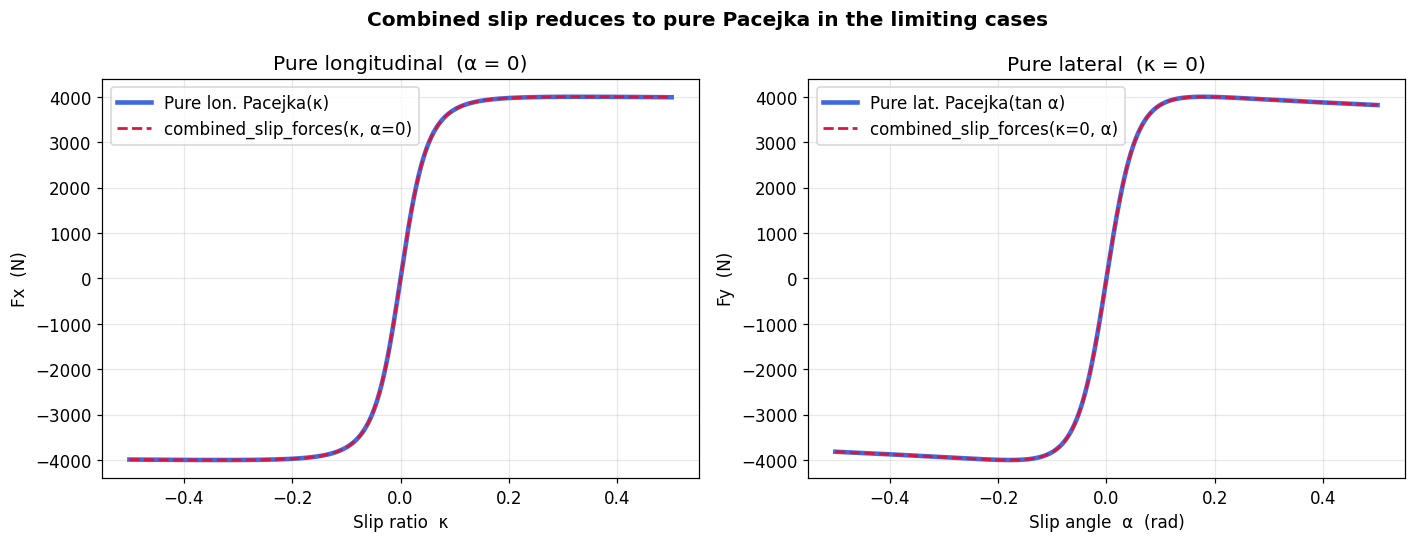

Max error pure lon: 0.0000 N
Max error pure lat: 0.0000 N


In [5]:
kappa_vals = np.linspace(-0.5, 0.5, 500)
alpha_vals = np.linspace(-0.5, 0.5, 500)
Fz_t       = 2500

# Pure longitudinal limit (α = 0)
Fx_comb_pure, Fy_zero = combined_slip_forces(kappa_vals, 0.0, Fz_t)
Fx_ref                = pacejka(kappa_vals, B_lon, C_lon, D_lon, E) * Fz_t

# Pure lateral limit (κ = 0)
Fx_zero, Fy_comb_pure = combined_slip_forces(0.0, alpha_vals, Fz_t)
Fy_ref                = pacejka(np.tan(alpha_vals), B_lat, C_lat, D_lat, E) * Fz_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Combined slip reduces to pure Pacejka in the limiting cases', fontweight='bold')

ax1.plot(kappa_vals, Fx_ref,       'royalblue', lw=3,   label='Pure lon. Pacejka(κ)')
ax1.plot(kappa_vals, Fx_comb_pure, 'crimson',   lw=1.8, ls='--', label='combined_slip_forces(κ, α=0)')
ax1.set_xlabel('Slip ratio  κ'); ax1.set_ylabel('Fx  (N)')
ax1.set_title('Pure longitudinal  (α = 0)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(alpha_vals, Fy_ref,       'royalblue', lw=3,   label='Pure lat. Pacejka(tan α)')
ax2.plot(alpha_vals, Fy_comb_pure, 'crimson',   lw=1.8, ls='--', label='combined_slip_forces(κ=0, α)')
ax2.set_xlabel('Slip angle  α  (rad)'); ax2.set_ylabel('Fy  (N)')
ax2.set_title('Pure lateral  (κ = 0)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Max error pure lon: {np.max(np.abs(Fx_comb_pure - Fx_ref)):.4f} N')
print(f'Max error pure lat: {np.max(np.abs(Fy_comb_pure - Fy_ref)):.4f} N')

## 5 — Braking sweep: Fy collapses as braking increases

Fix slip angle at α = 0.15 rad (moderate cornering, near peak).  Sweep κ from 0 → −0.4.

**Expected:** Fy starts near its pure-lateral value and falls as braking increases.
Total force |F| stays bounded near D × Fz.

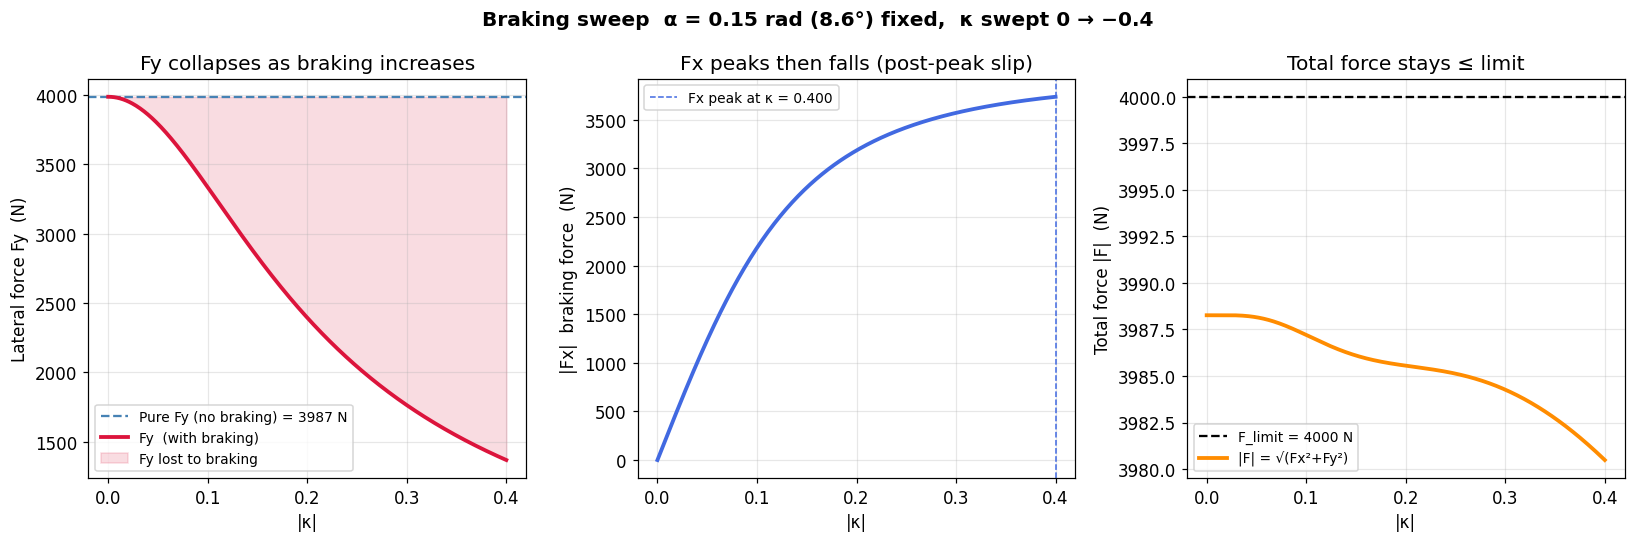

Fy at κ=0:     3987 N
Fy at κ=−0.40: 1369 N   (66% reduction)
Max |F| exceeds limit: False


In [6]:
alpha_fixed = 0.15
kappa_sw    = np.linspace(0, -0.40, 400)
Fz_sw       = 2500

Fx_sw, Fy_sw = combined_slip_forces(kappa_sw, alpha_fixed, Fz_sw)
Fy_no_brake  = pacejka(alpha_fixed, B_lat, C_lat, D_lat, E) * Fz_sw
F_total_sw   = np.sqrt(Fx_sw**2 + Fy_sw**2)
F_limit      = D_lon * Fz_sw

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Braking sweep  α = {alpha_fixed} rad ({np.degrees(alpha_fixed):.1f}°) fixed,  κ swept 0 → −0.4',
    fontweight='bold')

kabs = np.abs(kappa_sw)

axes[0].axhline(Fy_no_brake, color='steelblue', lw=1.5, ls='--',
                label=f'Pure Fy (no braking) = {Fy_no_brake:.0f} N')
axes[0].plot(kabs, Fy_sw, 'crimson', lw=2.5, label='Fy  (with braking)')
axes[0].fill_between(kabs, Fy_sw, Fy_no_brake, alpha=0.15, color='crimson',
                     label='Fy lost to braking')
axes[0].set_xlabel('|κ|'); axes[0].set_ylabel('Lateral force Fy  (N)')
axes[0].set_title('Fy collapses as braking increases')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(kabs, -Fx_sw, 'royalblue', lw=2.5)
pk_idx = int(np.argmax(-Fx_sw))
axes[1].axvline(kabs[pk_idx], color='royalblue', lw=1, ls='--',
                label=f'Fx peak at κ = {kabs[pk_idx]:.3f}')
axes[1].set_xlabel('|κ|'); axes[1].set_ylabel('|Fx|  braking force  (N)')
axes[1].set_title('Fx peaks then falls (post-peak slip)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].axhline(F_limit, color='black', lw=1.5, ls='--', label=f'F_limit = {F_limit:.0f} N')
axes[2].plot(kabs, F_total_sw, 'darkorange', lw=2.5, label='|F| = √(Fx²+Fy²)')
axes[2].set_xlabel('|κ|'); axes[2].set_ylabel('Total force |F|  (N)')
axes[2].set_title('Total force stays ≤ limit')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Fy at κ=0:     {Fy_no_brake:.0f} N')
print(f'Fy at κ=−0.40: {Fy_sw[-1]:.0f} N   ({(1 - Fy_sw[-1]/Fy_no_brake)*100:.0f}% reduction)')
print(f'Max |F| exceeds limit: {np.any(F_total_sw > F_limit + 0.5)}')

## 6 — The friction circle map: every (κ, α) combination

Dense grid of (κ, α) values → compute (Fx, Fy) → scatter plot.
All points should fall **inside** the friction circle.

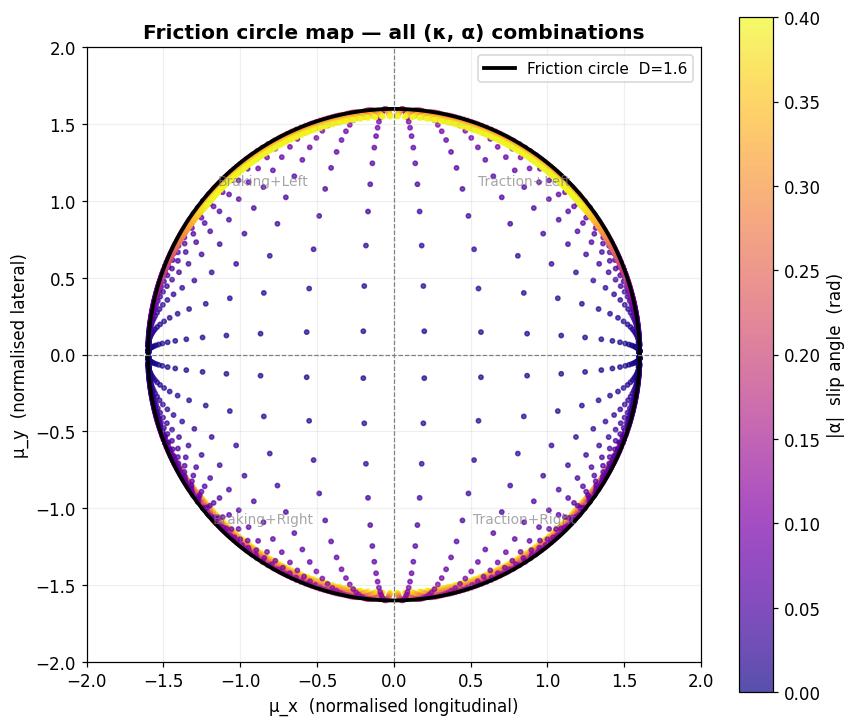

Max |F| across all samples: 4000.0 N
Friction limit:             4000.0 N
Any point exceeds limit:    False


In [7]:
kk  = np.linspace(-0.5,  0.5, 80)
aa  = np.linspace(-0.4,  0.4, 80)
KK, AA = np.meshgrid(kk, aa)

FX_g, FY_g = combined_slip_forces(KK.ravel(), AA.ravel(), 2500.0)
MX = (FX_g / 2500.0).reshape(KK.shape)
MY = (FY_g / 2500.0).reshape(KK.shape)

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(MX.ravel(), MY.ravel(),
                c=np.abs(AA.ravel()), cmap='plasma',
                s=8, alpha=0.7, vmin=0, vmax=0.4)
plt.colorbar(sc, ax=ax, label='|α|  slip angle  (rad)', shrink=0.8)

theta = np.linspace(0, 2*np.pi, 400)
ax.plot(D_lon * np.cos(theta), D_lat * np.sin(theta),
        'k-', lw=2.5, label='Friction circle  D=1.6')

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.text( 0.85,  1.1, 'Traction+Left', ha='center', fontsize=9, color='gray', alpha=0.7)
ax.text(-0.85,  1.1, 'Braking+Left',  ha='center', fontsize=9, color='gray', alpha=0.7)
ax.text(-0.85, -1.1, 'Braking+Right', ha='center', fontsize=9, color='gray', alpha=0.7)
ax.text( 0.85, -1.1, 'Traction+Right',ha='center', fontsize=9, color='gray', alpha=0.7)

ax.set_xlabel('μ_x  (normalised longitudinal)')
ax.set_ylabel('μ_y  (normalised lateral)')
ax.set_title('Friction circle map — all (κ, α) combinations', fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

F_all = np.sqrt(FX_g**2 + FY_g**2)
print(f'Max |F| across all samples: {F_all.max():.1f} N')
print(f'Friction limit:             {D_lon * 2500:.1f} N')
print(f'Any point exceeds limit:    {np.any(F_all > D_lon * 2500 + 0.1)}')

## 7 — F1 context: trail braking, ABS, and EBD

### Trail braking
Keeping the brake partially applied as you turn into a corner.  The driver deliberately
operates in the combined-slip region — spending some of the friction budget on braking
while also generating lateral force.

Why do it?
- **Load transfer to the front**: braking transfers Fz forward, increasing front tire normal
  load → front grip goes up (slightly), which compensates some of the friction circle cost
- **Car rotation**: rear becomes lighter → less rear lateral force → car rotates toward
  the apex.  Useful for slow-speed hairpins where rotation is more valuable than peak Fy.
- **Later brake point**: carry more entry speed, which is free time

The skill is transitioning smoothly from the braking axis to the lateral axis,
keeping the total force vector near the circle boundary the entire time.

### F1 has no ABS (banned since 1994)
The driver must modulate the pedal manually to keep κ near the peak without lockup.
Past the peak, braking force drops AND the wheel stops rotating → α cannot be generated
→ lateral force drops to near zero → understeer or straight-line slide regardless of steer.

### EBD — Electronic Brake-force Distribution
F1 drivers have a **brake bias adjuster** (cockpit-accessible during the lap).
Moving bias forward loads the front friction circle more → front tires lose lateral
grip sooner under braking → understeer.  Rear bias → rear tires lose lateral grip →
oversteer (rotation) under braking.  The correct setting changes corner to corner.

## 8 — Simulation: mid-corner brake application

Setup:
- Car cornering at 30 m/s, δ = 0.03 rad (steady-state turn)
- At t = 2 s: apply brake = 0.6 and hold
- Compare two models:
  - **Naive** (BicycleModel from notebook 03) — braking has no effect on Fy
  - **Combined** (CombinedBicycleModel) — braking correctly reduces Fy

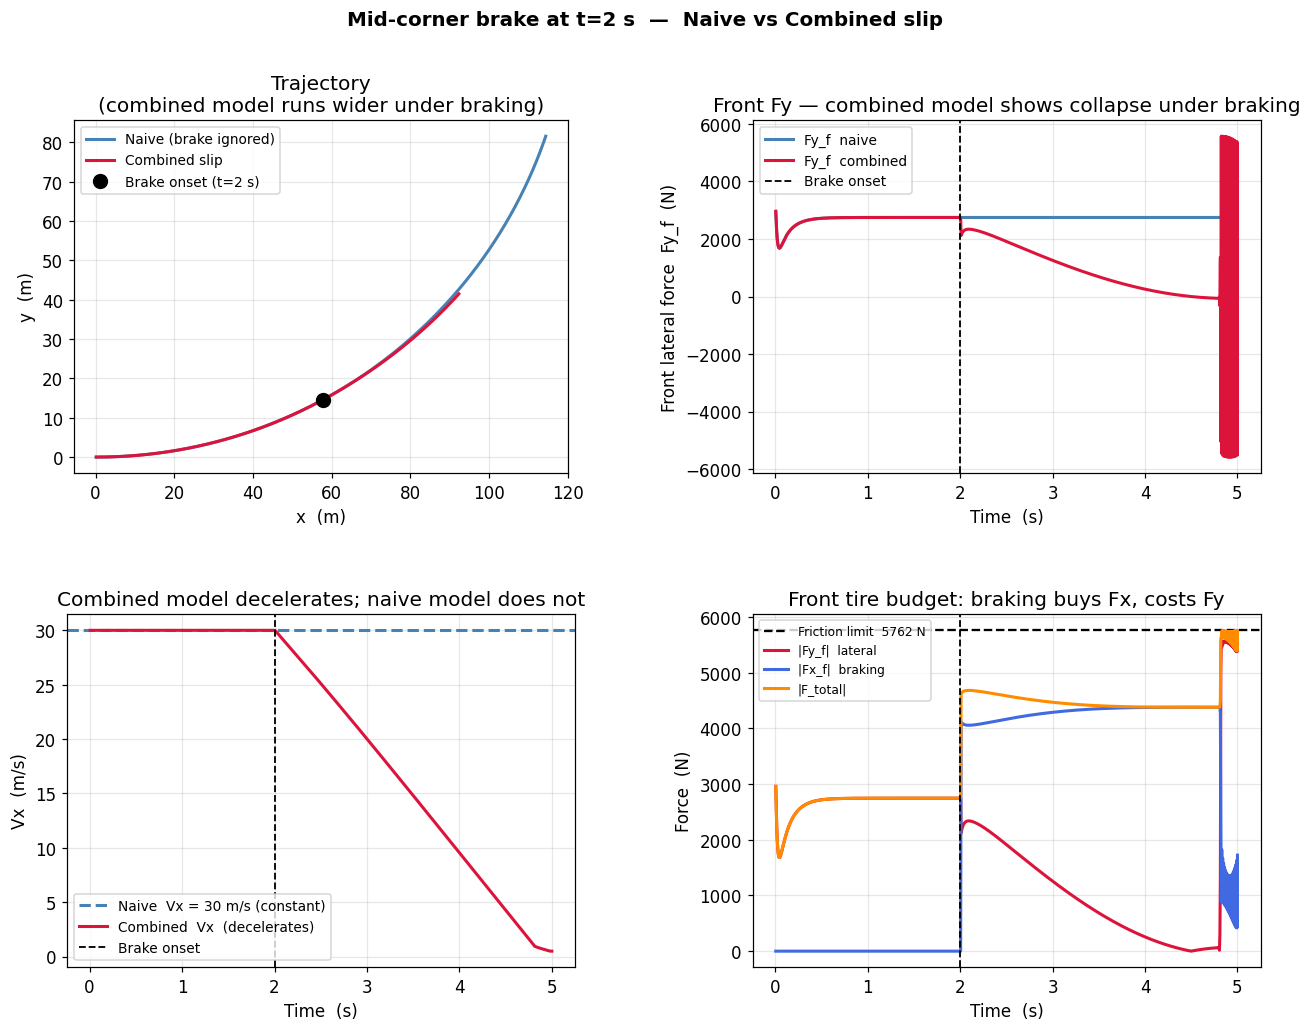

In [8]:
def run_combined_sim(brake_onset=2.0, brake_level=0.6, t_end=5.0, dt=0.005):
    car = CombinedBicycleModel(Vx=30.0)
    steps = int(t_end / dt)
    for _ in range(steps):
        brake = brake_level if car.t >= brake_onset else 0.0
        car.step(0.03, brake, dt)
    return car

def run_naive_sim(t_end=5.0, dt=0.005):
    car = BicycleModel(Vx=30.0)
    for _ in range(int(t_end / dt)):
        car.step(0.03, dt)
    return car

naive    = run_naive_sim()
combined = run_combined_sim()

hn = naive.history
hc = combined.history
t  = np.array(hc['t'])
tn = np.array(hn['t'])

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, fig, hspace=0.40, wspace=0.35)
fig.suptitle('Mid-corner brake at t=2 s  —  Naive vs Combined slip',
             fontsize=13, fontweight='bold')

# Trajectory
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hn['x'], hn['y'], 'steelblue', lw=2, label='Naive (brake ignored)')
ax1.plot(hc['x'], hc['y'], 'crimson',   lw=2, label='Combined slip')
idx = int(2.0 / 0.005)
ax1.plot(hc['x'][idx], hc['y'][idx], 'ko', ms=9, label='Brake onset (t=2 s)')
ax1.set_xlabel('x  (m)'); ax1.set_ylabel('y  (m)')
ax1.set_title('Trajectory\n(combined model runs wider under braking)')
ax1.set_aspect('equal'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Fy_f over time
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tn, hn['Fy_f'], 'steelblue', lw=2, label='Fy_f  naive')
ax2.plot(t,  hc['Fy_f'], 'crimson',   lw=2, label='Fy_f  combined')
ax2.axvline(2.0, color='black', lw=1.2, ls='--', label='Brake onset')
ax2.set_xlabel('Time  (s)'); ax2.set_ylabel('Front lateral force  Fy_f  (N)')
ax2.set_title('Front Fy — combined model shows collapse under braking')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Vx over time
ax3 = fig.add_subplot(gs[1, 0])
ax3.axhline(30.0, color='steelblue', lw=2, ls='--', label='Naive  Vx = 30 m/s (constant)')
ax3.plot(t, hc['Vx'], 'crimson', lw=2, label='Combined  Vx  (decelerates)')
ax3.axvline(2.0, color='black', lw=1.2, ls='--', label='Brake onset')
ax3.set_xlabel('Time  (s)'); ax3.set_ylabel('Vx  (m/s)')
ax3.set_title('Combined model decelerates; naive model does not')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# Front tire force budget
ax4 = fig.add_subplot(gs[1, 1])
F_tot_f = np.sqrt(np.array(hc['Fx_f'])**2 + np.array(hc['Fy_f'])**2)
F_lim_f = 1.6 * CombinedBicycleModel.FZ_F
ax4.axhline(F_lim_f, color='black', lw=1.5, ls='--', label=f'Friction limit  {F_lim_f:.0f} N')
ax4.plot(t, np.abs(hc['Fy_f']), 'crimson',    lw=2, label='|Fy_f|  lateral')
ax4.plot(t, np.abs(hc['Fx_f']), 'royalblue',  lw=2, label='|Fx_f|  braking')
ax4.plot(t, F_tot_f,             'darkorange', lw=2, label='|F_total|')
ax4.axvline(2.0, color='black', lw=1.2, ls='--')
ax4.set_xlabel('Time  (s)'); ax4.set_ylabel('Force  (N)')
ax4.set_title('Front tire budget: braking buys Fx, costs Fy')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.show()

## 9 — Brake bias: how distribution affects balance

More front brake bias → front tires enter combined slip more heavily → front Fy
drops more → **understeer** under braking.
More rear brake bias → rear tires enter combined slip more → rear Fy drops →
**oversteer** under braking (dangerous at high speed).

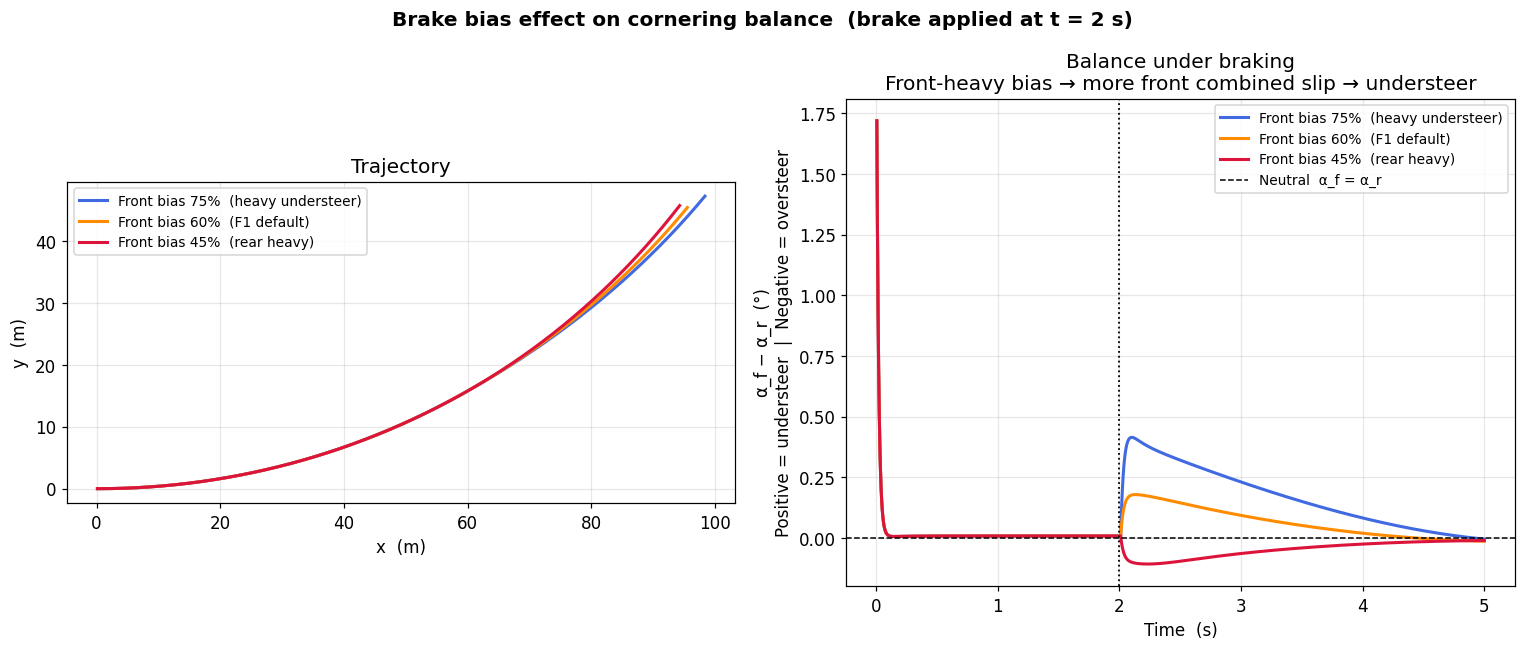

In [9]:
from combined_slip import combined_slip_forces as csf
from bicycle_model import (
    M as M_car, IZ, A as A_ax, B as B_ax, FZ_F, FZ_R,
    B_LON, C_LON, B_LAT, C_LAT, E_PAC, KAPPA_AT_FULL_BRAKE
)

def run_bias(bias_f, brake_level=0.5, brake_onset=2.0, t_end=5.0, dt=0.005):
    """Minimal simulation loop with a custom brake bias, bypassing the class default."""
    # State
    Vx = 30.0; Vy = 0.0; psi = 0.0; pd = 0.0; x = 0.0; y = 0.0; t = 0.0
    D = 1.6
    history = {'t': [], 'x': [], 'y': [], 'alpha_f': [], 'alpha_r': [], 'psi_dot': []}

    for _ in range(int(t_end / dt)):
        delta = 0.03
        brake = brake_level if t >= brake_onset else 0.0

        if Vx > 0.5:
            alpha_f = delta - np.arctan2(Vy + A_ax * pd, Vx)
            alpha_r =       - np.arctan2(Vy - B_ax * pd, Vx)
        else:
            alpha_f = alpha_r = 0.0

        kappa_f = -brake * KAPPA_AT_FULL_BRAKE * bias_f
        kappa_r = -brake * KAPPA_AT_FULL_BRAKE * (1.0 - bias_f)

        Fx_f, Fy_f = csf(kappa_f, alpha_f, FZ_F, B_LON, C_LON, D, E_PAC, B_LAT, C_LAT, D, E_PAC)
        Fx_r, Fy_r = csf(kappa_r, alpha_r, FZ_R, B_LON, C_LON, D, E_PAC, B_LAT, C_LAT, D, E_PAC)

        dVx = (Fx_f + Fx_r) / M_car
        dVy = (Fy_f + Fy_r) / M_car - Vx * pd
        dpd = (A_ax * Fy_f - B_ax * Fy_r) / IZ

        Vx = max(0.5, Vx + dVx * dt)
        Vy += dVy * dt
        pd += dpd * dt
        psi += pd * dt
        speed = np.sqrt(Vx**2 + Vy**2)
        x += speed * np.cos(psi) * dt
        y += speed * np.sin(psi) * dt
        t += dt

        history['t'].append(t)
        history['x'].append(x)
        history['y'].append(y)
        history['alpha_f'].append(np.degrees(alpha_f))
        history['alpha_r'].append(np.degrees(alpha_r))
        history['psi_dot'].append(pd)

    return history

bias_setups = [
    (0.75, 'Front bias 75%  (heavy understeer)',  'royalblue'),
    (0.60, 'Front bias 60%  (F1 default)',        'darkorange'),
    (0.45, 'Front bias 45%  (rear heavy)',        'crimson'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Brake bias effect on cornering balance  (brake applied at t = 2 s)', fontweight='bold')

for bias, label, color in bias_setups:
    h = run_bias(bias)
    t_arr = np.array(h['t'])
    ax1.plot(h['x'], h['y'], color=color, lw=2, label=label)
    ax2.plot(t_arr, np.array(h['alpha_f']) - np.array(h['alpha_r']),
             color=color, lw=2, label=label)

ax1.set_xlabel('x  (m)'); ax1.set_ylabel('y  (m)')
ax1.set_title('Trajectory')
ax1.set_aspect('equal'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.axhline(0,   color='black', lw=1,   ls='--', label='Neutral  α_f = α_r')
ax2.axvline(2.0, color='black', lw=1.2, ls=':')
ax2.set_xlabel('Time  (s)')
ax2.set_ylabel('α_f − α_r  (°)\nPositive = understeer  |  Negative = oversteer')
ax2.set_title('Balance under braking\nFront-heavy bias → more front combined slip → understeer')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10 — Summary

**What we built:**

| Concept | Key formula | Takeaway |
|---------|-------------|----------|
| Friction circle | √(Fx²+Fy²) ≤ μ_peak·Fz | Grip is a shared budget |
| Combined slip σ | σ = √(κ² + tan²α) | Total slip magnitude seen by contact patch |
| Slip vector decomposition | Fx=(κ/σ)·Pac(σ)·Fz, Fy=(tanα/σ)·Pac(σ)·Fz | Friction circle enforced automatically |
| Braking costs cornering | Fy falls as \|κ\| rises | Every N of braking costs cornering N |
| Brake bias | Front → understeer, Rear → oversteer | Controls which axle pays the combined-slip cost |

**New lib files created this notebook:**
- `lib/combined_slip.py` — `combined_slip_forces(kappa, alpha, Fz, ...)`
- `lib/bicycle_model.py` — `BicycleModel` (from notebook 03) + `CombinedBicycleModel`

**What's still missing:**

1. **Weight transfer** — braking shifts Fz forward: front loads up, rear unloads.
   This changes D per axle mid-corner, feeding back into the combined slip forces.
   The friction circle *expands* at the front and *shrinks* at the rear under braking.
   → **notebook 05**

2. **Aerodynamics** — at high speed, downforce adds to Fz (and therefore D×Fz),
   expanding the friction circle speed-dependently.
   → **notebook 06**

3. **4-wheel model** — separate left/right tires; roll transfers load under cornering;
   driven vs undriven axle have different traction slip.
   → **notebook 07**

When you're ready, say **done** and we'll move on to notebook 05 — weight transfer.